# Phase 2: Exploratory Data Analysis

**BOL-LPP Reproduction Project**

This notebook explores the raw datasets downloaded in Phase 1 before any preprocessing, to inform decisions made in Phase 3.

**Goals:**
- Characterise the distribution of ERCOT day-ahead prices, including negative prices and scarcity spikes
- Examine temporal patterns in load and price (hour-of-day, day-of-week, seasonal)
- Assess the load–price relationship and correlations between candidate input features
- Identify missing values and gaps in each dataset
- Verify that the price, load, and weather series align on a common hourly timestamp index

**Inputs:** `data/raw/ercot_dam_spp_zones_2013_2018.csv`, `data/raw/ercot_hourly_load_zones_2013_2018.csv`, `data/raw/weather_north_2013_2018.csv`

---
**Author:** Jahandad Irfan

## 2.1 Price distribution

The paper reports BOL-LPP achieving MAE of $0.0044/MWh on the North zone (Table 2). Before
reproducing anything, it is worth establishing the actual scale of ERCOT day-ahead prices,
since that reported figure implies an error of well under one cent per MWh.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RAW_DIR = Path("../data/raw")

prices = pd.read_csv(RAW_DIR / "ercot_dam_spp_zones_2013_2018.csv")
load = pd.read_csv(RAW_DIR / "ercot_hourly_load_zones_2013_2018.csv")
weather = pd.read_csv(RAW_DIR / "weather_north_2013_2018.csv")

print(prices.groupby("Zone")["SPP"].describe().round(2))

         count   mean    std   min    25%    50%    75%      max
Zone                                                            
Coast  52584.0  30.97  39.63  1.26  20.37  25.79  34.56  2250.00
North  52584.0  29.41  39.36  1.48  19.67  24.71  32.69  2241.43
South  52584.0  31.72  40.55  0.56  20.80  26.44  34.96  2250.73


### Observations

Across all three zones, day-ahead prices average roughly $30/MWh with a standard deviation
near $39. The distribution is heavily right-skewed: the mean exceeds the median in every zone
(e.g. Coast: mean $30.97 vs median $25.79), and the maximum reaches approximately $2,250/MWh,
around 75x the mean. Most hours are unremarkable; a small number of scarcity events dominate
the upper tail.

No negative prices occur in this period (minima range from $0.56 to $1.48). Negative day-ahead
prices became substantially more common in ERCOT after 2019 as wind capacity expanded, so the
2013-2018 window predates that regime. This avoids undefined MAPE values, though prices near
$0.56 still produce very large percentage errors, which is a plausible explanation for the
~48% MAPE reported in the paper.

The three zones are tightly coupled: means fall within $2 of each other, standard deviations
are near-identical, and maxima cluster around $2,250, consistent with a common system-wide
offer cap binding during scarcity events.

### Implications for the reported metrics

An MAE of $0.0044/MWh against a series with mean $30 and standard deviation $39 corresponds to
an average error of roughly 0.015% of the mean. This is not plausible for a volatile price
series and would imply near-perfect prediction of scarcity spikes.

Two further observations suggest the deep-learning metrics in Table 2 are not on the original
price scale:

1. **Internal inconsistency within Table 2.** SARIMAX (MAE 8.003) and XGBoost (MAE 6.88) report
   values consistent with dollar units, while BiLSTM (0.0065) and BOL-LPP (0.0044) are three
   orders of magnitude smaller on the same dataset. A unit change between model families is a
   more parsimonious explanation than a genuine accuracy difference of that size.

2. **MAE and MAPE cannot both hold.** BOL-LPP reports MAE 0.0044 alongside MAPE 48.7%. An
   average error of 0.015% cannot coexist with an average percentage error of 48.7% on the same
   predictions in the same units. Both become internally consistent if MAE is computed on
   normalised values while MAPE is computed against actual prices.

The paper states that "feature normalization is employed" without specifying the method, so the
exact transform cannot be determined from the text. This reproduction therefore reports metrics
both on the normalised scale (comparable to the paper's deep-learning figures) and inverse-
transformed to $/MWh (comparable to the classical baselines and economically interpretable).

In [2]:
load_all_check = pd.read_csv(RAW_DIR / "ercot_hourly_load_zones_2013_2018.csv")
print(load_all_check.groupby("Zone")["Load_MW"].describe())

         count          mean          std          min          25%  \
Zone                                                                  
Coast  52583.0  11498.074572  2605.482810  6602.878600  9621.753046   
North  52583.0    838.262200   176.104025   522.306095   714.309402   
South  52583.0   3322.099543   824.131500  1665.982938  2708.097051   

                50%           75%           max  
Zone                                             
Coast  10873.786330  12906.846477  20269.849015  
North    794.614491    931.604563   1521.845309  
South   3157.162653   3849.347735   6176.106417  


In [3]:
import gridstatus
ercot = gridstatus.Ercot()

sample = ercot.get_hourly_load_post_settlements(date="2016-07-01", end="2016-07-07")
zone_cols = ["Coast", "East", "Far West", "North", "North Central",
             "South", "South Central", "West", "ERCOT"]
print(sample[zone_cols].mean().round(0))

2026-09-04 21:29:10 - INFO - Fetching historical load data for year 2016
2026-09-04 21:29:11 - DEBUG - Changing timezone for DST duplicate at 2016-11-06 01:00:00-06:00


Coast            11694.0
East              1398.0
Far West          2143.0
North              823.0
North Central    12953.0
South             3395.0
South Central     6484.0
West              1115.0
ERCOT            40006.0
dtype: float64


## 2.2 Visualising the price distribution

The summary statistics indicate strong right skew. Plotting on a linear y-axis makes the bulk
of the distribution visible but hides the tail entirely; a log-scaled y-axis reveals the rare
high-price hours. Both views are shown for comparison.

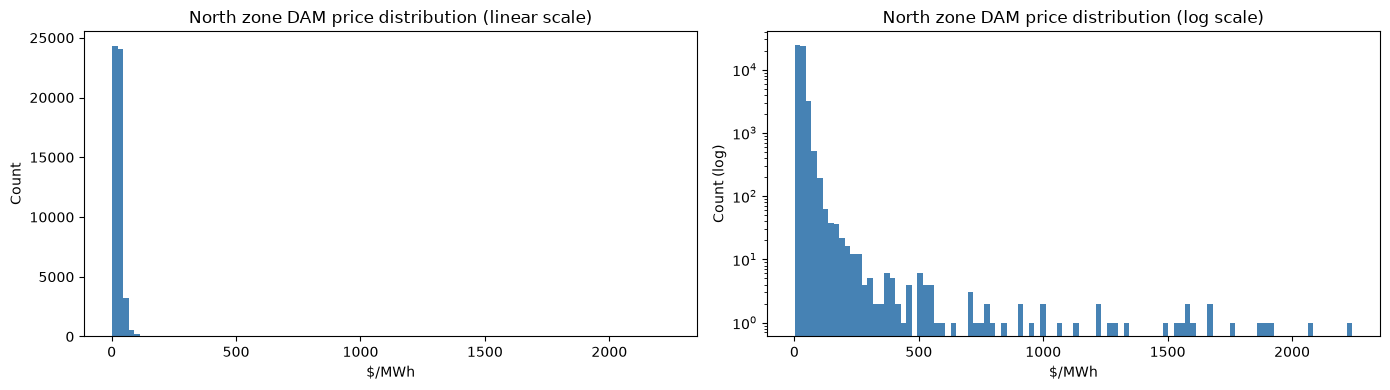

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

north = prices[prices["Zone"] == "North"]["SPP"]

axes[0].hist(north, bins=100, color="steelblue")
axes[0].set_title("North zone DAM price distribution (linear scale)")
axes[0].set_xlabel("$/MWh")
axes[0].set_ylabel("Count")

axes[1].hist(north, bins=100, color="steelblue")
axes[1].set_yscale("log")
axes[1].set_title("North zone DAM price distribution (log scale)")
axes[1].set_xlabel("$/MWh")
axes[1].set_ylabel("Count (log)")

plt.tight_layout()
plt.savefig("../results/figures/price_distribution_north.png", dpi=150, bbox_inches="tight")
plt.show()

### Observations

On a linear scale the distribution collapses to a single bar near zero: hours above ~$100/MWh
are too infrequent to be visible against roughly 24,000 hours in the lowest bucket. The
log-scaled panel reveals the structure, with counts decaying approximately log-linearly from
10^4 down to isolated single-hour observations above $2,000/MWh across the full six-year period.

Two consequences follow for modelling:

- A model trained to minimise MSE or MAE on this distribution will be dominated by the ~99% of
  hours below $100/MWh, and has little incentive to fit the tail. Spike hours are therefore
  likely to be systematically under-predicted, which is where the extension in Phase 8 is
  targeted.
- The skew makes the choice of scaling consequential. Min-max normalisation maps the $2,250
  maximum to 1.0 and compresses the bulk of the data into a very narrow band near zero, which
  in turn makes normalised-scale error metrics appear extremely small. This is consistent with
  the magnitude of the MAE values reported for the deep-learning models in the original paper.

## 2.3 Temporal patterns

Electricity demand and price follow strong cyclical patterns driven by human activity and
weather. Establishing these patterns confirms that the calendar features used by the paper
(hour, day, month, year) carry genuine signal, and indicates which cycles the model needs to
capture.

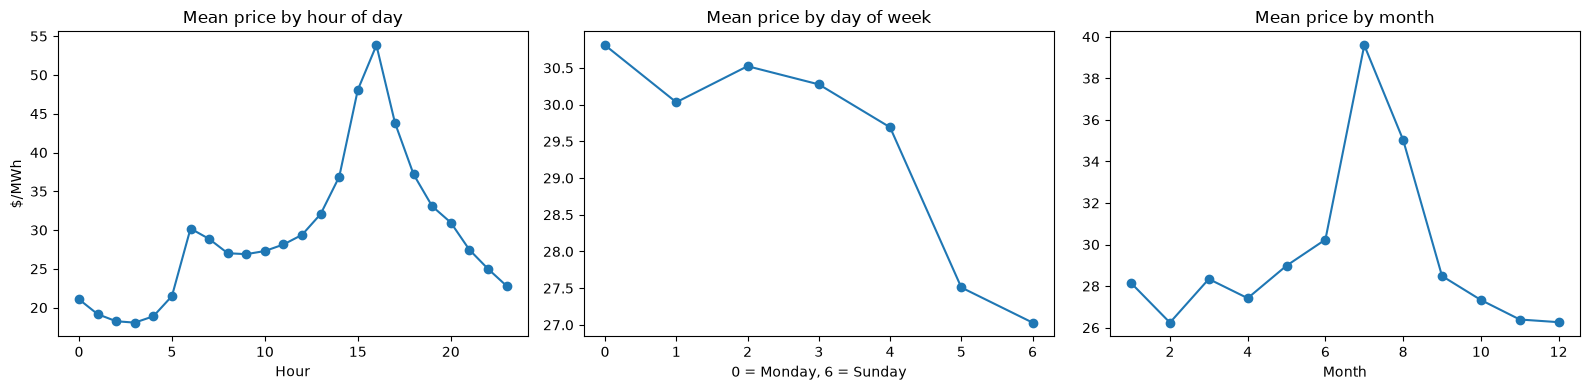

In [6]:
p = prices[prices["Zone"] == "North"].copy()
p["Interval Start"] = pd.to_datetime(p["Interval Start"], utc=True).dt.tz_convert("America/Chicago")
p["hour"] = p["Interval Start"].dt.hour
p["dayofweek"] = p["Interval Start"].dt.dayofweek
p["month"] = p["Interval Start"].dt.month

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

p.groupby("hour")["SPP"].mean().plot(ax=axes[0], marker="o")
axes[0].set_title("Mean price by hour of day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("$/MWh")

p.groupby("dayofweek")["SPP"].mean().plot(ax=axes[1], marker="o")
axes[1].set_title("Mean price by day of week")
axes[1].set_xlabel("0 = Monday, 6 = Sunday")

p.groupby("month")["SPP"].mean().plot(ax=axes[2], marker="o")
axes[2].set_title("Mean price by month")
axes[2].set_xlabel("Month")

plt.tight_layout()
plt.savefig("../results/figures/price_temporal_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

## 2.4 Load-price relationship and feature correlations

Load is the model's primary input and price its target, so the strength and shape of that
relationship determines how much of the forecasting problem load alone can solve. This section
merges the three raw datasets on a common hourly index for the North zone and examines the
pairwise correlations among all candidate features.

In [7]:
# --- Prepare price ---
pr = prices[prices["Zone"] == "North"][["Interval Start", "SPP"]].copy()
pr["ts"] = pd.to_datetime(pr["Interval Start"], utc=True).dt.tz_convert("America/Chicago").dt.tz_localize(None)
pr = pr[["ts", "SPP"]]

# --- Prepare load ---
ld = load[load["Zone"] == "North"][["Interval Start", "Load_MW"]].copy()
ld["ts"] = pd.to_datetime(ld["Interval Start"], utc=True).dt.tz_convert("America/Chicago").dt.tz_localize(None)
ld = ld[["ts", "Load_MW"]]

# --- Prepare weather ---
wx = weather.copy()
wx["ts"] = pd.to_datetime(wx["time"])
wx = wx.drop(columns=["time"])

# --- Merge ---
df = pr.merge(ld, on="ts", how="inner").merge(wx, on="ts", how="inner")
print("Merged shape:", df.shape)
print("Date range:", df["ts"].min(), "to", df["ts"].max())
print("Missing values:\n", df.isna().sum())

Merged shape: (52596, 7)
Date range: 2013-01-01 00:00:00 to 2018-12-31 23:00:00
Missing values:
 ts                   0
SPP                  0
Load_MW              1
temperature_2m       0
dewpoint_2m          0
windspeed_10m        0
winddirection_10m    0
dtype: int64


### Timestamp alignment issues

The merge produced 52,596 rows against an expected 52,584, and one missing load value. Both are
consequences of daylight saving transitions.

In November, clocks move back and the 1:00-2:00 am hour occurs twice. ERCOT distinguishes the
two occurrences by timezone offset (CDT `-05:00` then CST `-06:00`), but stripping the offset to
enable merging with the timezone-naive weather data collapses them to identical timestamps,
producing duplicate matches. Six years of data yields twelve extra rows.

In March, clocks move forward and the 2:00 am hour does not occur, which is the likely source of
the single missing load value.

The diagnostic below confirms whether the affected timestamps fall on DST transition dates.

In [8]:
dupes = df[df.duplicated("ts", keep=False)]
print("Duplicate timestamps:", len(dupes))
print(dupes[["ts", "SPP", "Load_MW"]].head(8))

print("\nMissing load rows:")
print(df[df["Load_MW"].isna()][["ts", "SPP", "Load_MW"]])

Duplicate timestamps: 24
                       ts    SPP      Load_MW
7344  2013-11-03 01:00:00  23.18  7913.708211
7345  2013-11-03 01:00:00  23.18  8054.862364
7346  2013-11-03 01:00:00  20.45  7913.708211
7347  2013-11-03 01:00:00  20.45  8054.862364
16082 2014-11-02 01:00:00  19.03  8156.648178
16083 2014-11-02 01:00:00  19.03  8283.784751
16084 2014-11-02 01:00:00  18.84  8156.648178
16085 2014-11-02 01:00:00  18.84  8283.784751

Missing load rows:
                       ts    SPP  Load_MW
33751 2016-11-06 23:00:00  14.69      NaN


## 2.5 Feature correlations

Correlation quantifies how strongly each candidate input moves with price. This indicates which
features carry predictive signal and whether any are redundant with each other. Values range
from -1 (perfect inverse relationship) through 0 (no linear relationship) to +1 (perfect
positive relationship).

Note that correlation captures only *linear* association. A feature with near-zero correlation
may still be informative if its relationship with price is non-linear, which an LSTM can learn
but this statistic will not reveal.

SPP                  1.000
Load_MW              0.307
hour                 0.119
temperature_2m       0.095
month                0.001
winddirection_10m   -0.016
dewpoint_2m         -0.017
dayofweek           -0.031
windspeed_10m       -0.039
Name: SPP, dtype: float64


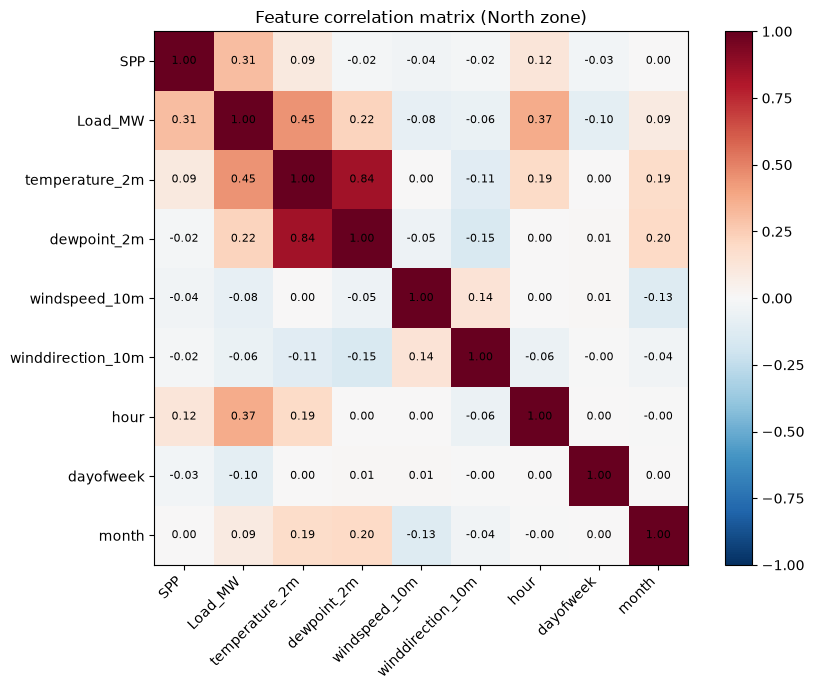

In [9]:
df_clean = df.drop_duplicates("ts").copy()
df_clean["Load_MW"] = df_clean["Load_MW"].interpolate()

df_clean["hour"] = df_clean["ts"].dt.hour
df_clean["dayofweek"] = df_clean["ts"].dt.dayofweek
df_clean["month"] = df_clean["ts"].dt.month

corr = df_clean[["SPP", "Load_MW", "temperature_2m", "dewpoint_2m",
                 "windspeed_10m", "winddirection_10m", "hour", "dayofweek", "month"]].corr()

print(corr["SPP"].sort_values(ascending=False).round(3))

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
plt.colorbar(im)
ax.set_title("Feature correlation matrix (North zone)")

for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("../results/figures/correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

### Pearson vs Spearman

`.corr()` computes Pearson correlation, which measures linear association only. Spearman
correlation ranks the values before correlating them, so it captures any consistently
increasing or decreasing relationship regardless of shape. Comparing the two indicates
whether the load-price relationship is genuinely weak or simply non-linear.

In [10]:
pearson = df_clean[["SPP", "Load_MW"]].corr().iloc[0, 1]
spearman = df_clean[["SPP", "Load_MW"]].corr(method="spearman").iloc[0, 1]
print(f"Pearson:  {pearson:.3f}")
print(f"Spearman: {spearman:.3f}")

Pearson:  0.307
Spearman: 0.560


### Result

Pearson correlation between load and price is 0.31; Spearman correlation is 0.56. The
substantial gap indicates the relationship is strong and monotonic — higher load reliably
corresponds to higher price — but non-linear in shape. Spearman captures this because it
correlates ranks rather than raw values, and is therefore insensitive to curvature.

This provides direct empirical support for the paper's motivation: linear models such as ARMA,
ARIMA, and SARIMAX cannot represent this relationship fully, while an LSTM with non-linear
activations can. The Pearson value alone would understate the predictive signal available in
the load series.